# Explainability — Credit Card Fraud Detection

**Goal:** Understand why the model predicts fraud. Global feature importance and individual transaction explanations.

### Sections
1. Setup & Load Model
2. Global Feature Importance (SHAP)
3. SHAP Summary Plot
4. SHAP Bar Plot
5. Individual Prediction Explanations
6. Fraud vs Legitimate — Average SHAP Comparison
7. Feature Dependence Plots
8. Key Insights

---
## 1. Setup & Load Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import warnings
import os, sys

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

FRAUD_COLOR  = '#ef4444'
LEGIT_COLOR  = '#3b82f6'
TARGET       = 'Class'

print('Libraries loaded')

Libraries loaded


In [2]:
# Load model and data
pipeline = joblib.load('../models/best_model_pipeline.pkl')

with open('../models/optimal_threshold.json') as f:
    threshold_info = json.load(f)
threshold = threshold_info['threshold']

with open('../models/feature_names.json') as f:
    feature_info = json.load(f)
numeric_cols     = feature_info['numeric']
categorical_cols = feature_info['categorical']

test_df = pd.read_csv('../data/processed/test.csv')
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

print(f'Model loaded: {type(pipeline.named_steps["classifier"]).__name__}')
print(f'Threshold: {threshold:.3f}')
print(f'Test set: {X_test.shape} | Fraud cases: {y_test.sum():,}')

Model loaded: RandomForestClassifier
Threshold: 0.072
Test set: (56746, 33) | Fraud cases: 95


In [3]:
# Extract preprocessor and classifier from pipeline
preprocessor = pipeline.named_steps['preprocessor']
classifier   = pipeline.named_steps['classifier']

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Get all encoded feature names
try:
    ohe_features = preprocessor.named_transformers_['cat']['onehot']\
                               .get_feature_names_out(categorical_cols).tolist()
except Exception:
    ohe_features = []

all_feature_names = numeric_cols + ohe_features

print(f'Transformed test shape: {X_test_transformed.shape}')
print(f'Total features: {len(all_feature_names)}')

Transformed test shape: (56746, 35)
Total features: 35


---
## 2. Compute SHAP Values

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value
for each prediction. Positive SHAP = pushes toward fraud. Negative SHAP = pushes toward legitimate.

We use a sample of 2,000 test transactions for speed.

In [11]:
explainer   = shap.TreeExplainer(classifier)
shap_values_raw = explainer.shap_values(X_shap)

print(f'Raw SHAP shape: {np.array(shap_values_raw).shape}')

# XGBoost returns shape (n_samples, n_features, 2) — take class 1 (fraud)
if np.array(shap_values_raw).ndim == 3:
    shap_values = np.array(shap_values_raw)[:, :, 1]
elif isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    shap_values = shap_values_raw

print(f'SHAP values shape after fix: {shap_values.shape}')
print(f'Feature names length: {len(all_feature_names)}')
print('SHAP values computed successfully')

Raw SHAP shape: (1095, 35, 2)
SHAP values shape after fix: (1095, 35)
Feature names length: 35
SHAP values computed successfully


---
## 3. SHAP Summary Plot

Each dot is one transaction. Red = high feature value, Blue = low feature value.
X-axis = SHAP value (how much that feature pushed the prediction toward fraud).

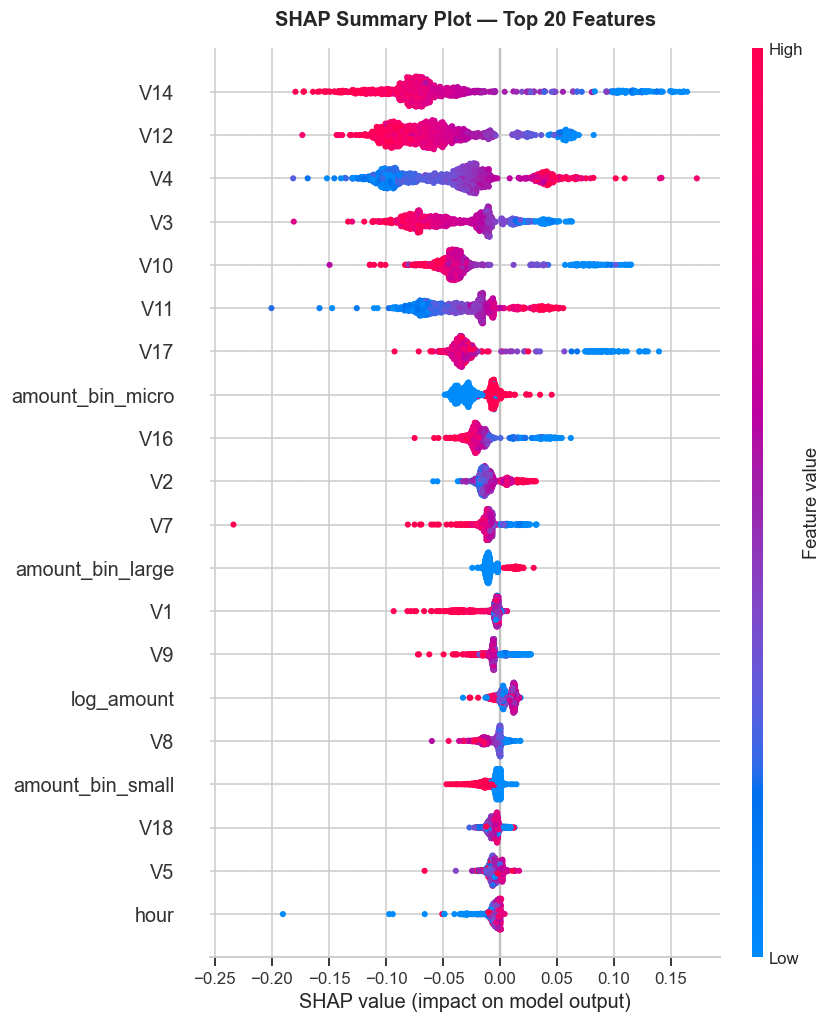

In [12]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=all_feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — Top 20 Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 4. SHAP Bar Plot — Mean Absolute Importance

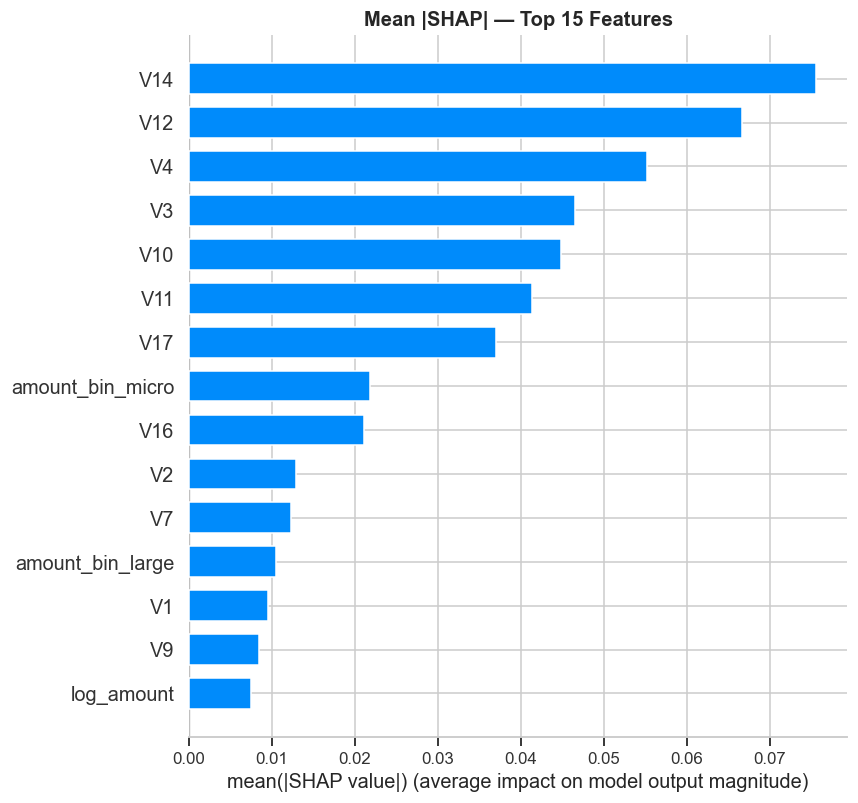

=== Top 15 Features by SHAP Importance ===
         Feature  Mean |SHAP|
             V14     0.075593
             V12     0.066643
              V4     0.055155
              V3     0.046519
             V10     0.044908
             V11     0.041317
             V17     0.037013
amount_bin_micro     0.021839
             V16     0.021132
              V2     0.012862
              V7     0.012299
amount_bin_large     0.010471
              V1     0.009514
              V9     0.008463
      log_amount     0.007504


In [13]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Mean |SHAP| — Top 15 Features', fontweight='bold')
plt.tight_layout()
plt.show()

# Print top features as a table
mean_shap = np.abs(shap_values).mean(axis=0).flatten()
shap_importance = pd.DataFrame({
    'Feature':     all_feature_names[:len(mean_shap)],
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False).head(15)

print('=== Top 15 Features by SHAP Importance ===')
print(shap_importance.to_string(index=False))

In [14]:
print(f'shap_values shape:     {shap_values.shape}')
print(f'all_feature_names len: {len(all_feature_names)}')
print(f'mean_shap shape:       {mean_shap.shape}')

shap_values shape:     (1095, 35)
all_feature_names len: 35
mean_shap shape:       (35,)


---
## 5. Individual Prediction Explanations

Waterfall plots show exactly why the model flagged a specific transaction as fraud.

Explaining transaction index: 9
Actual label: FRAUD
Predicted probability: 1.0000


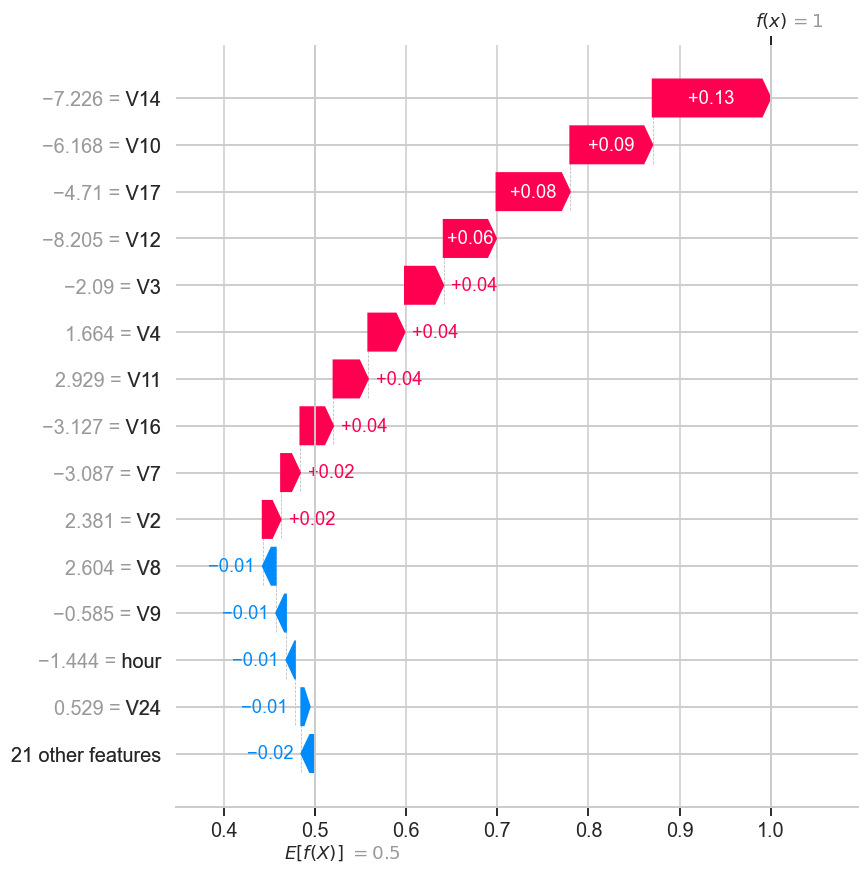

In [16]:
fraud_probs = classifier.predict_proba(X_shap)[:, 1]
fraud_cases = np.where(y_shap == 1)[0]
high_conf_fraud_idx = fraud_cases[np.argmax(fraud_probs[fraud_cases])]

print(f'Explaining transaction index: {high_conf_fraud_idx}')
print(f'Actual label: FRAUD')
print(f'Predicted probability: {fraud_probs[high_conf_fraud_idx]:.4f}')

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(np.array(base_val).flatten()[1])
else:
    base_val = float(base_val)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_conf_fraud_idx],
        base_values=base_val,
        data=X_shap[high_conf_fraud_idx],
        feature_names=all_feature_names
    ),
    max_display=15
)

Explaining transaction index: 95
Actual label: LEGITIMATE
Predicted probability: 0.0000


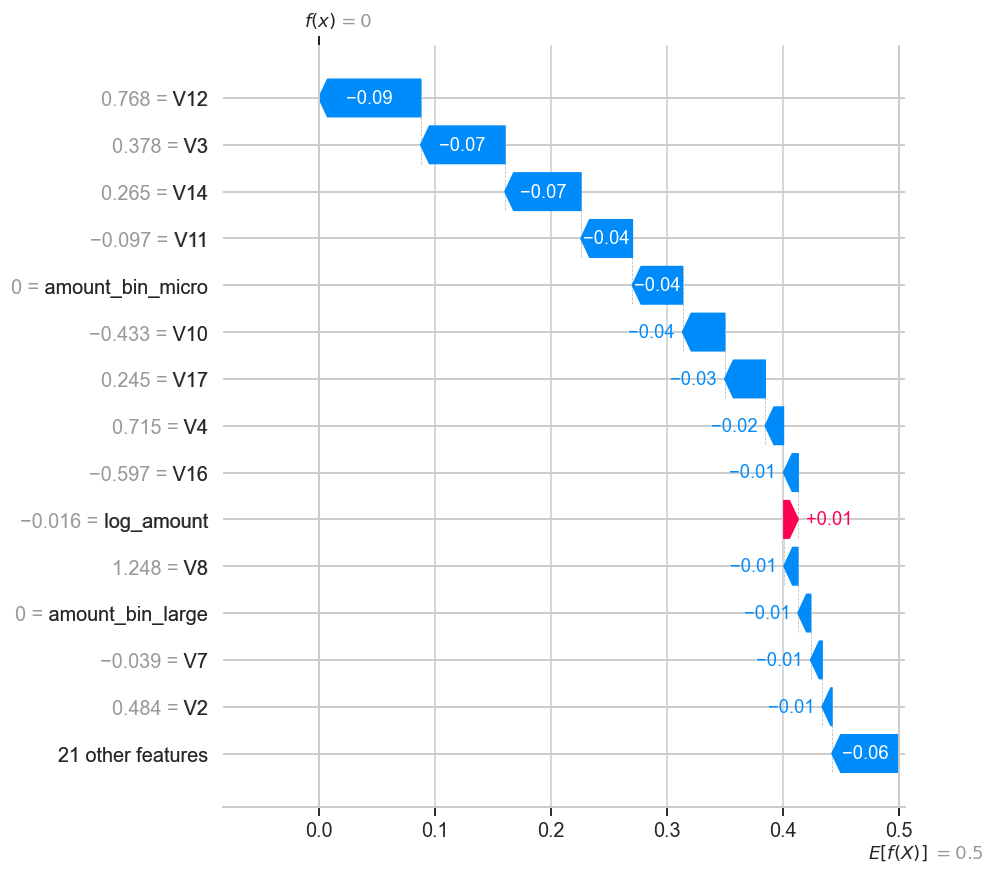

In [17]:
legit_cases = np.where(y_shap == 0)[0]
low_conf_legit_idx = legit_cases[np.argmin(fraud_probs[legit_cases])]

print(f'Explaining transaction index: {low_conf_legit_idx}')
print(f'Actual label: LEGITIMATE')
print(f'Predicted probability: {fraud_probs[low_conf_legit_idx]:.4f}')

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_conf_legit_idx],
        base_values=base_val,
        data=X_shap[low_conf_legit_idx],
        feature_names=all_feature_names
    ),
    max_display=15
)

---
## 6. Fraud vs Legitimate — Average SHAP Comparison

Compare how each feature contributes on average for fraud vs legitimate transactions.

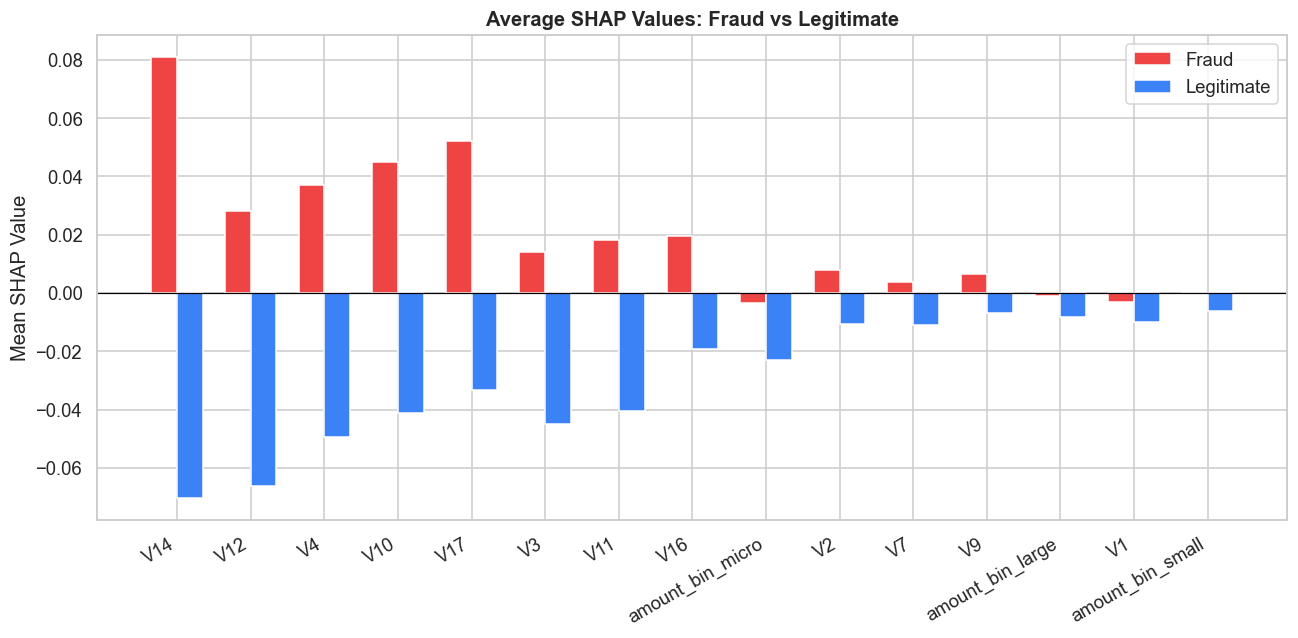

In [18]:
fraud_shap = shap_values[y_shap == 1]
legit_shap = shap_values[y_shap == 0]

mean_fraud_shap = fraud_shap.mean(axis=0)
mean_legit_shap = legit_shap.mean(axis=0)

# Top features by difference
diff = mean_fraud_shap - mean_legit_shap
top_idx = np.abs(diff).argsort()[::-1][:15]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top_idx))
width = 0.35
ax.bar(x - width/2, mean_fraud_shap[top_idx], width,
       label='Fraud', color=FRAUD_COLOR, edgecolor='white')
ax.bar(x + width/2, mean_legit_shap[top_idx], width,
       label='Legitimate', color=LEGIT_COLOR, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([all_feature_names[i] for i in top_idx],
                   rotation=30, ha='right')
ax.set_title('Average SHAP Values: Fraud vs Legitimate', fontweight='bold')
ax.set_ylabel('Mean SHAP Value')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Feature Dependence Plots

Shows how a feature's value relates to its SHAP contribution.
Points coloured by fraud label.

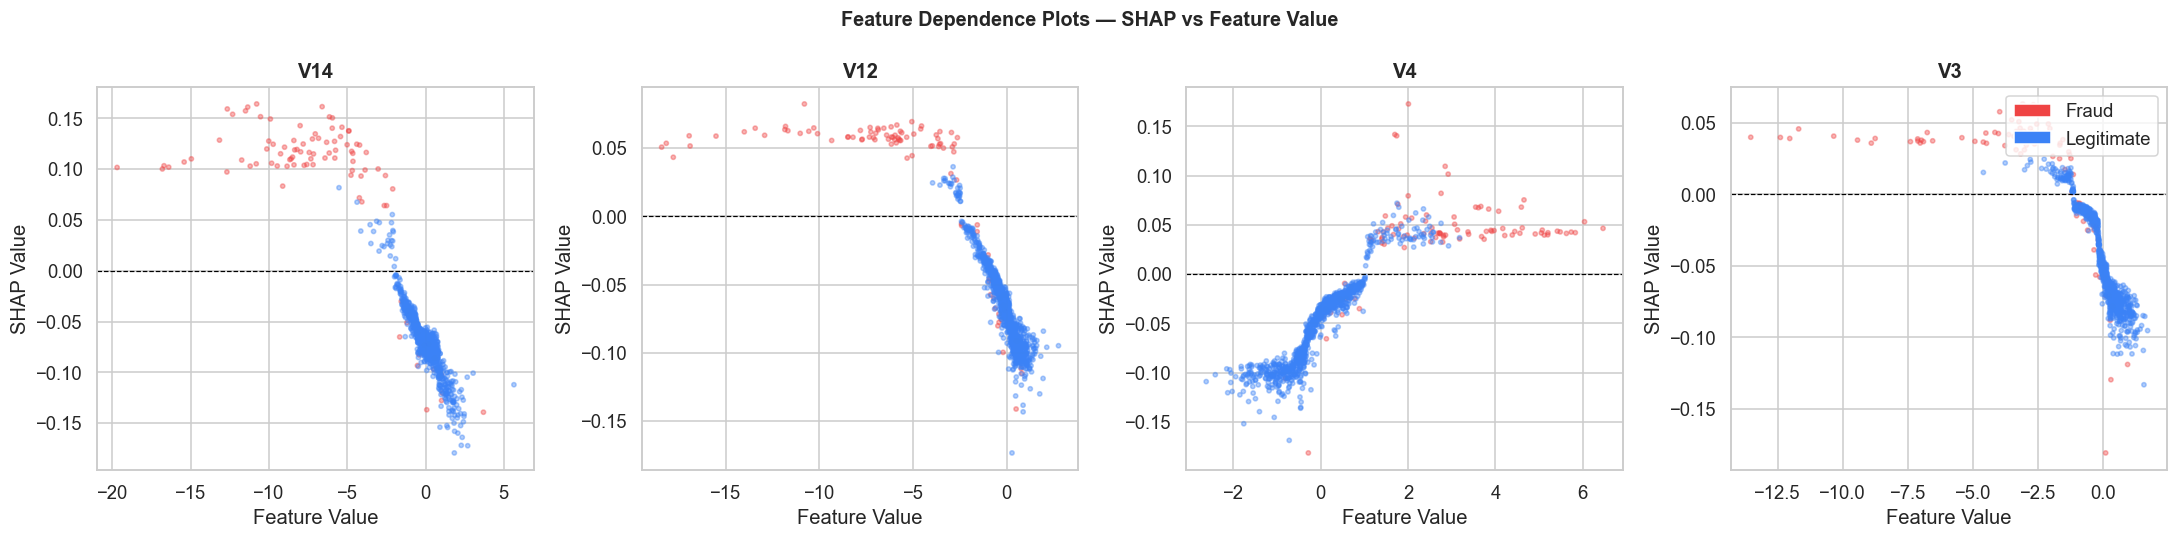

In [19]:
# Plot dependence for top 4 most important features
top_features = shap_importance['Feature'].head(4).tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, feat in zip(axes, top_features):
    if feat in all_feature_names:
        feat_idx  = all_feature_names.index(feat)
        feat_vals = X_shap[:, feat_idx]
        shap_vals = shap_values[:, feat_idx]
        colors    = [FRAUD_COLOR if y == 1 else LEGIT_COLOR for y in y_shap]

        ax.scatter(feat_vals, shap_vals, c=colors, alpha=0.4, s=8)
        ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(feat, fontweight='bold')
        ax.set_xlabel('Feature Value')
        ax.set_ylabel('SHAP Value')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=FRAUD_COLOR, label='Fraud'),
    Patch(facecolor=LEGIT_COLOR, label='Legitimate')
]
axes[-1].legend(handles=legend_elements, loc='upper right')

plt.suptitle('Feature Dependence Plots — SHAP vs Feature Value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Key Insights

In [20]:
top5 = shap_importance['Feature'].head(5).tolist()

print('=================================================================')
print('                   EXPLAINABILITY SUMMARY')
print('=================================================================')
print()
print('  TOP 5 MOST IMPORTANT FEATURES (by Mean |SHAP|)')
for i, feat in enumerate(top5, 1):
    val = shap_importance.loc[shap_importance['Feature']==feat, 'Mean |SHAP|'].values[0]
    print(f'  {i}. {feat:<30s} {val:.4f}')
print()
print('  INTERPRETATION')
print('  - Positive SHAP value = feature pushes prediction toward FRAUD')
print('  - Negative SHAP value = feature pushes prediction toward LEGITIMATE')
print('  - Magnitude = how strongly the feature influences the prediction')
print()
print('  BUSINESS USE')
print('  - Investigators can see exactly why a transaction was flagged')
print('  - Top features can guide rule-based fallback systems')
print('  - Dependence plots reveal non-linear fraud patterns')
print()
print('  NEXT STEP -> FastAPI + Streamlit deployment')
print('=================================================================')

                   EXPLAINABILITY SUMMARY

  TOP 5 MOST IMPORTANT FEATURES (by Mean |SHAP|)
  1. V14                            0.0756
  2. V12                            0.0666
  3. V4                             0.0552
  4. V3                             0.0465
  5. V10                            0.0449

  INTERPRETATION
  - Positive SHAP value = feature pushes prediction toward FRAUD
  - Negative SHAP value = feature pushes prediction toward LEGITIMATE
  - Magnitude = how strongly the feature influences the prediction

  BUSINESS USE
  - Investigators can see exactly why a transaction was flagged
  - Top features can guide rule-based fallback systems
  - Dependence plots reveal non-linear fraud patterns

  NEXT STEP -> FastAPI + Streamlit deployment
